In [44]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: c:\Users\Pikachu\AppData\Local\Programs\Python\Python312\python.exe
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("A:\\iam_pikabyte\\CSV_Files&Pdf's\\titanic_data_updated.csv")

In [47]:
df.shape

(891, 12)

In [48]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [49]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
761,762,no,third,"Nirva, Mr. Iisakki Antino Aijo",male,41.0,0,0,SOTON/O2 3101272,7.1250,NaN,S
879,880,yes,first,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
370,371,yes,first,"Harder, Mr. George Achilles",male,25.0,1,0,11765,55.4417,E50,C
501,502,no,third,"Canavan, Miss. Mary",female,21.0,0,0,364846,7.7500,NaN,Q
753,754,no,third,"Jonkoff, Mr. Lalio",male,23.0,0,0,349204,7.8958,NaN,S
368,369,yes,third,"Jermyn, Miss. Annie",female,NaN,0,0,14313,7.7500,NaN,Q
399,400,yes,second,"Trout, Mrs. William H (Jessie L)",female,28.0,0,0,240929,12.6500,NaN,S
467,468,no,first,"Smart, Mr. John Montgomery",male,56.0,0,0,113792,26.5500,NaN,S
800,801,no,second,"Ponesell, Mr. Martin",male,34.0,0,0,250647,13.0000,NaN,S
123,124,yes,second,"Webber, Miss. Susan",female,32.5,0,0,27267,13.0000,E101,S


In [50]:
# missing Values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [51]:
# checking duplicacy
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [53]:
# Works only with numerical features
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


## Univariate Analysis {Categorical}

<Axes: xlabel='Survived', ylabel='count'>

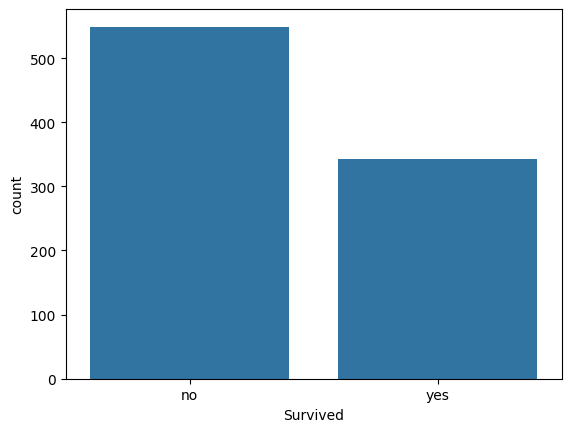

In [54]:
sns.countplot(data=df, x= df["Survived"])

In [55]:
(df['Survived'].value_counts()/len(df))* 100

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64

['no' 'yes']


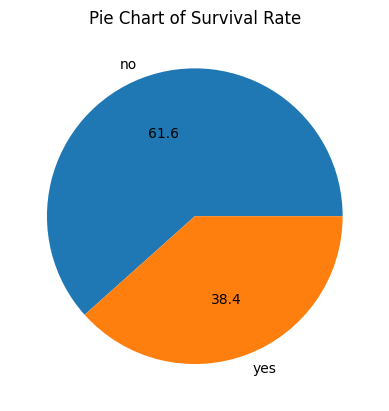

In [56]:
survived_count = df['Survived'].value_counts()
survived_label = df['Survived'].unique()
print(survived_label)
plt.pie(survived_count, labels=survived_label, autopct="%1.1f")
plt.title('Pie Chart of Survival Rate')
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

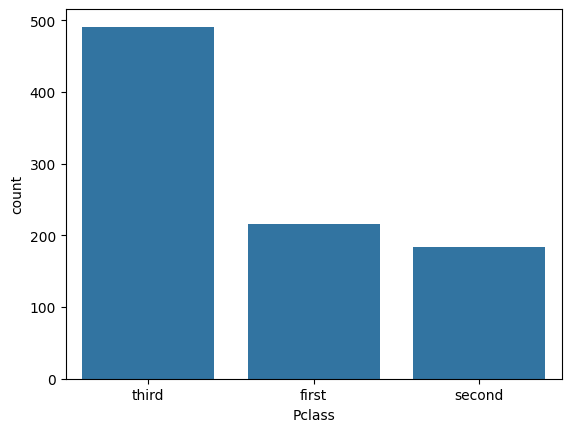

In [57]:
sns.countplot(data=df, x=df['Pclass'])

In [58]:
(df['Pclass'].value_counts()/len(df))*100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

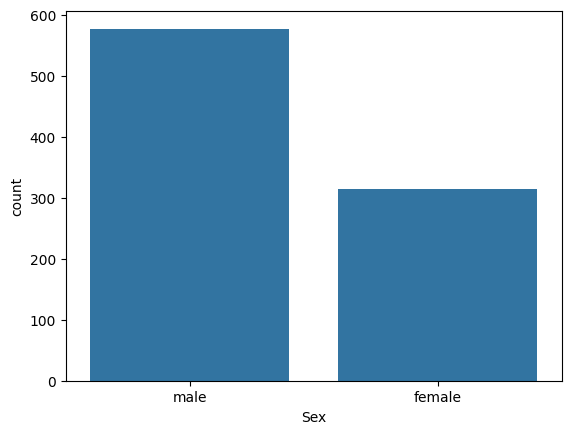

In [59]:
sns.countplot(data=df, x=df['Sex'])

In [60]:
(df['Sex'].value_counts()/len(df))*100

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

<Axes: xlabel='Embarked', ylabel='count'>

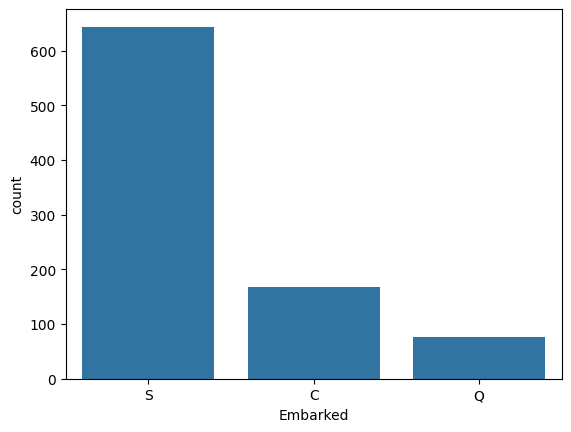

In [61]:
sns.countplot(data=df, x=df['Embarked'])

In [62]:
(df['Embarked'].value_counts()/len(df))*100

Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64

## Univariate Analysis {Numerical}

Text(0, 0.5, 'Frequency')

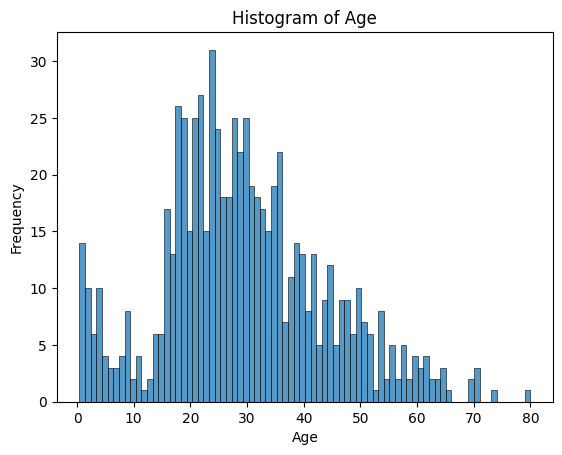

In [63]:
sns.histplot(df['Age'],bins=80)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

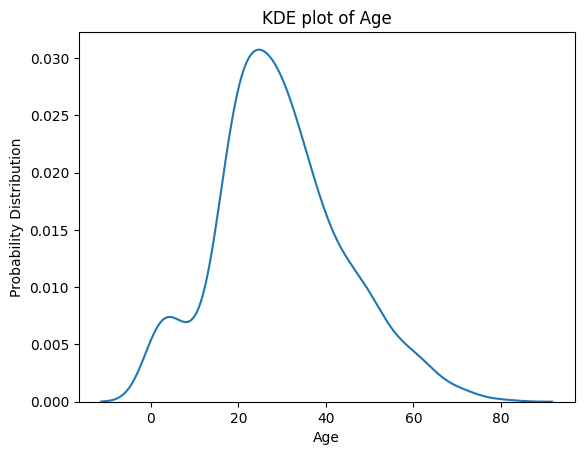

In [64]:
sns.kdeplot(df['Age'])
plt.title('KDE plot of Age')
plt.xlabel('Age')
plt.ylabel('Probability Distribution')
plt.show()

Text(0.5, 1.0, 'Distribution of Fare')

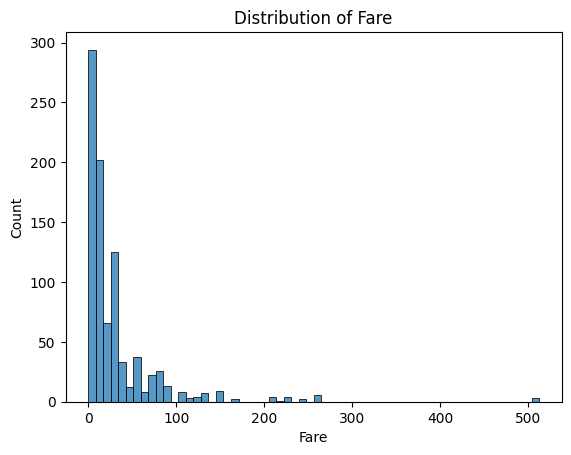

In [65]:
sns.histplot(df['Fare'])
plt.title('Distribution of Fare')

Text(0.5, 1.0, 'Distribution of Fare')

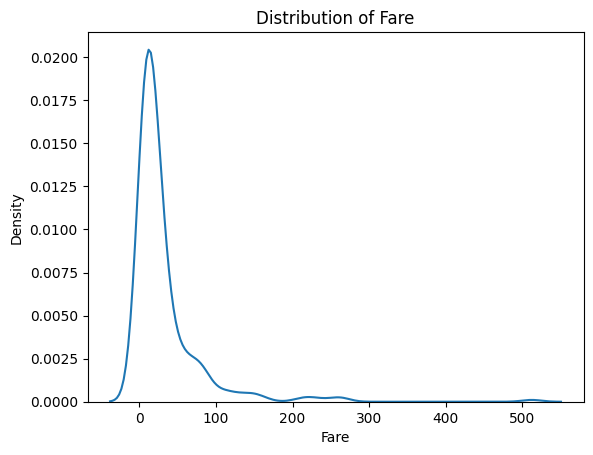

In [66]:
sns.kdeplot(df['Fare'])
plt.title('Distribution of Fare')

<Axes: ylabel='Fare'>

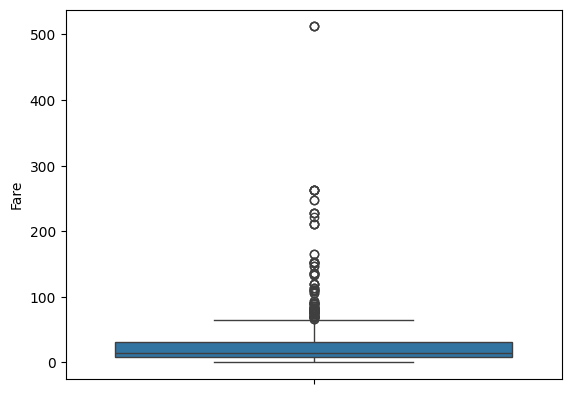

In [67]:
sns.boxplot(df['Fare'])

## Multivariate Analysis

<Axes: xlabel='Sex', ylabel='count'>

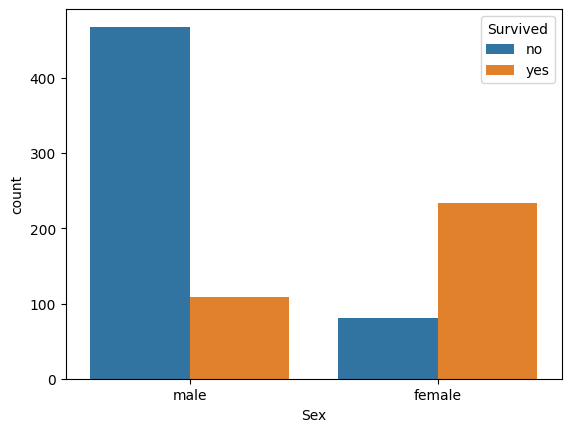

In [68]:
sns.countplot(x=df['Sex'], hue=df['Survived'])

In [69]:
gender_split = df.groupby('Sex')['Survived'].value_counts(normalize=True)
print(gender_split)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

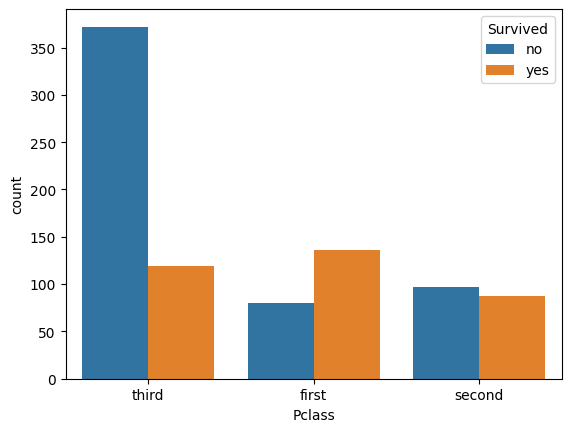

In [70]:
sns.countplot(x=df['Pclass'], hue=df['Survived'])

In [71]:
Pclass_split = df.groupby('Pclass')['Survived'].value_counts(normalize=True)
print(Pclass_split)

Pclass  Survived
first   yes         0.629630
        no          0.370370
second  no          0.527174
        yes         0.472826
third   no          0.757637
        yes         0.242363
Name: proportion, dtype: float64


<Axes: xlabel='Pclass', ylabel='Fare'>

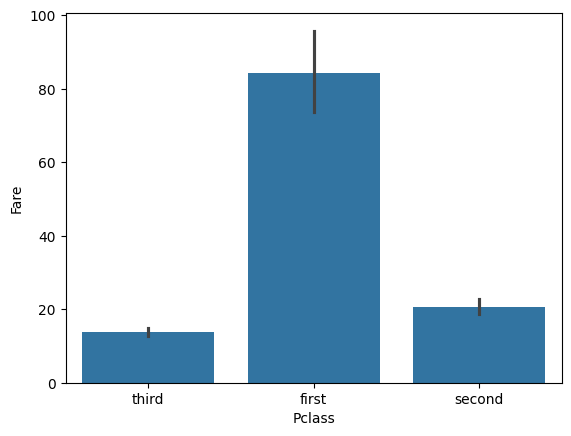

In [72]:
sns.barplot(x=df['Pclass'],y=df['Fare'])

<Axes: xlabel='Survived', ylabel='Age'>

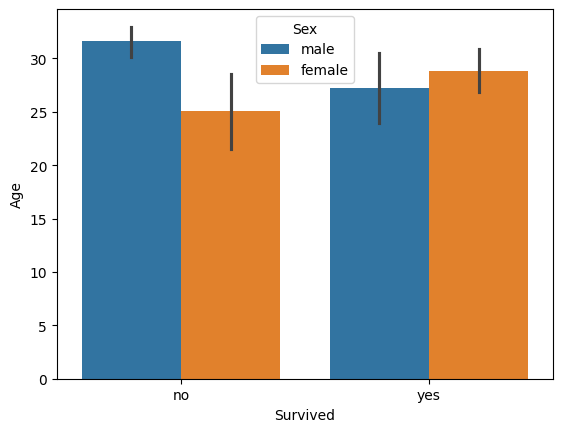

In [73]:
sns.barplot(x=df['Survived'],y=df['Age'],hue=df['Sex'])

# Density Graph

<Axes: xlabel='Age', ylabel='Density'>

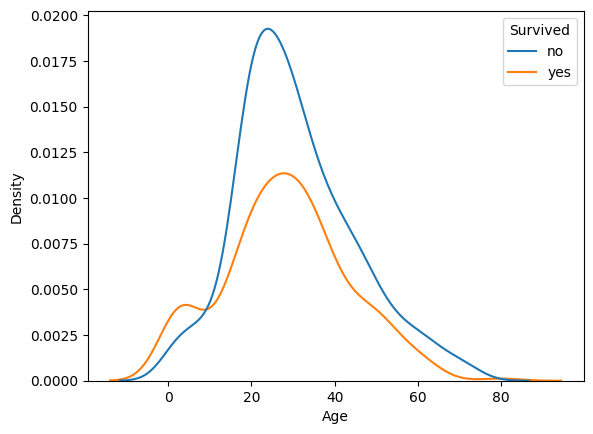

In [74]:
sns.kdeplot(data=df, x='Age',hue='Survived')

In [75]:
# df = sns.load_dataset('tips')
# df

In [76]:
# sns.scatterplot(data=df,x='total_bill', y='tip', hue='sex', size='size')

In [77]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='Titanic Profile Report')
profile.to_file('titanic_report.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 73.26it/s]
